 # Preparacion de los datos

In [6]:
import pandas as pd

df = pd.read_csv('Churn.csv')

#Eliminaremos los valores faltantes en el data set pues representan menos del 10%, podemos descartarlos con la seguridad de que la cantidad de datos aun es viable para entrenar nuestro modelo.
df = df.dropna()

#Para evitar que el modelo interprete datos irrelevantes vamos a eliminar las columnas que no representan informacion valiosa para la prediccion RowNumber, CustomerId, Surname
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

#Tenemos dos variables categoricas que podemos procesar con OHE 'Gender' y 'Geography'
#df = pd.concat([df, pd.get_dummies(df['Gender'], drop_first=True), pd.get_dummies(df['Geography'], drop_first=True)], axis=1)

print(df.shape)
print(df.info())
print(df.head())

(9091, 11)
<class 'pandas.DataFrame'>
Index: 9091 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      9091 non-null   int64  
 1   Geography        9091 non-null   str    
 2   Gender           9091 non-null   str    
 3   Age              9091 non-null   int64  
 4   Tenure           9091 non-null   float64
 5   Balance          9091 non-null   float64
 6   NumOfProducts    9091 non-null   int64  
 7   HasCrCard        9091 non-null   int64  
 8   IsActiveMember   9091 non-null   int64  
 9   EstimatedSalary  9091 non-null   float64
 10  Exited           9091 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 852.3 KB
None
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42     2.0       0.00              1   
1          608     Spain  Female   41     1.0   83807.86              1   
2         

# Examinar el equilibrio de clases

Conteo de clases:  Exited
0    7237
1    1854
Name: count, dtype: int64
Porcentaje de los datos:  Exited
0    79.606204
1    20.393796
Name: proportion, dtype: float64


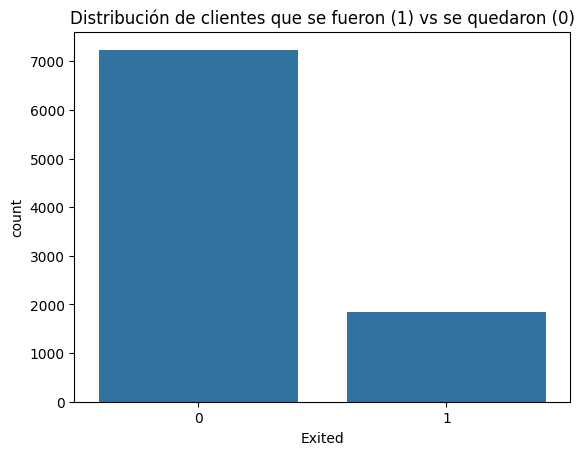

In [7]:
print('Conteo de clases: ', df['Exited'].value_counts())
print('Porcentaje de los datos: ', df['Exited'].value_counts(normalize=True) * 100)

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.title('Distribución de clientes que se fueron (1) vs se quedaron (0)')
plt.show()

El data set esta desbalanceado, los clientes que se fueron representa un cuarto del conjunto de los datos

## Entrenamiento del modelo sin considerar el desequilibrio de los datos

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

#separamos el target de las caracteristicas
features = df.drop(['Exited'], axis=1)
target = df['Exited']

#Hagamos un split del conjunto de los datos para entrenamiento, validacion y prueba 
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=12345, stratify=target)

#Codificamos las variables categoricas para que no causen error al entrenar el modelo
features_train = pd.get_dummies(features_train, columns=['Geography', 'Gender'], drop_first=True)
features_train = features_train.astype(int)
features_valid = pd.get_dummies(features_valid, columns=['Geography', 'Gender'], drop_first=True)
features_valid = features_valid.astype(int)

#Entrenemos un modelo y veamos los resultados de las  metricas
model =RandomForestClassifier(n_estimators=200, max_depth=10, random_state=12345)
model.fit(features_train, target_train)
predictions_valid = model.predict(features_valid)

print("=== RESULTADOS - MODELO SIN CORREGIR DESEQUILIBRIO ===")
print(f"{'Conjunto':<12} {'F1 Score':<10} {'AUC-ROC':<10} {'Accuracy':<10}")
print("-" * 45)

print(f"{'Validación':<12} {f1_score(target_valid, predictions_valid):.4f}     "
      f"{roc_auc_score(target_valid, predictions_valid):.4f}     "
      f"{accuracy_score(target_valid, predictions_valid):.4f}")

# Matriz de confusión (muy útil para entender el problema)
print("\nMatriz de Confusión (Validación):")
print(confusion_matrix(target_valid, predictions_valid))

=== RESULTADOS - MODELO SIN CORREGIR DESEQUILIBRIO ===
Conjunto     F1 Score   AUC-ROC    Accuracy  
---------------------------------------------
Validación   0.6146     0.7337     0.8720

Matriz de Confusión (Validación):
[[1750   59]
 [ 232  232]]


Sin tomar en cuenta el desbalance vemos que l valor de la precision es elevado, sin embargo los valores de los tros indicadores no son tan buenos
# Mejorando el modelo

Corrijamos el desbalance con distintos metodos.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Enfoque 1: class_weight='balanced'
print("1. RandomForest con class_weight='balanced'")

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=12345,
    class_weight='balanced'
)

model.fit(features_train, target_train)
predictions_valid = model.predict(features_valid)

print(f"F1 Valid: {f1_score(target_valid, predictions_valid):.4f} | AUC-ROC: {roc_auc_score(target_valid, predictions_valid):.4f} | {accuracy_score(target_valid, predictions_valid):.4f}")
print("\nMatriz de Confusión (Validación):")
print(confusion_matrix(target_valid, predictions_valid))

# Enfoque 2: LogisticRegresion + class_weight='balanced'
print("\n2. LogisticRegresion + class_weight='balanced'")

model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=12345)
model.fit(features_train, target_train)
predictions_valid = model.predict(features_valid)

print(f"F1 Valid: {f1_score(target_valid, predictions_valid):.4f} | AUC-ROC: {roc_auc_score(target_valid, predictions_valid):.4f} | {accuracy_score(target_valid, predictions_valid):.4f}")
print("\nMatriz de Confusión (Validación):")
print(confusion_matrix(target_valid, predictions_valid))

1. RandomForest con class_weight='balanced'
F1 Valid: 0.6305 | AUC-ROC: 0.7643 | 0.8531

Matriz de Confusión (Validación):
[[1654  155]
 [ 179  285]]

2. LogisticRegresion + class_weight='balanced'
F1 Valid: 0.4689 | AUC-ROC: 0.6857 | 0.6731

Matriz de Confusión (Validación):
[[1202  607]
 [ 136  328]]


# Prueba final, mejor modelo.

In [16]:
print("PRUEBA FINAL")

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=12345,
    class_weight='balanced'
)

model.fit(features_train, target_train)
predictions_valid = model.predict(features_valid)

# Métricas finales
f1_test = f1_score(target_valid, predictions_valid)
auc_test = roc_auc_score(target_valid, predictions_valid)

print(f"F1 Score (Test)  : {f1_test:.4f}")
print(f"AUC-ROC (Test)   : {auc_test:.4f}")
print(f"Accuracy (Test)  : {accuracy_score(target_valid, predictions_valid):.4f}")

print("\nMatriz de Confusión en Test:")
print(confusion_matrix(target_valid, predictions_valid))


PRUEBA FINAL
F1 Score (Test)  : 0.6305
AUC-ROC (Test)   : 0.7643
Accuracy (Test)  : 0.8531

Matriz de Confusión en Test:
[[1654  155]
 [ 179  285]]
